# Istanbul House Rent Prediction

<img src='https://www.ekoturk.com/wp-content/uploads/2025/07/Istanbul-kira-artis-Istanbul.jpg'>

Bu çalışmada, İstanbul’daki kiralık konut ilanları Selenium kullanılarak derlenmiş; ancak ilanlarda fiyat, metrekare ve bina yaşı gibi kritik değişkenlerin eksik olması nedeniyle, güncel piyasa dinamiklerini yansıtacak şekilde kapsamlı bir veri simülasyonu gerçekleştirilmiştir.

Simülasyon sürecinde; ilçe ve mahalle bazında kira seviyeleri, metrekare dağılımları, yapı yaşı, lçe/mahalle bazında sosyo-ekonomik gelişmişlik göstergeleri, bölgesel kademelenme yapısı ve kentsel dönüşüm alanları, güncel piyasa eğilimleri gibi faktörler dikkate alınarak gerçeğe en yakın olacak şekilde veri seti oluşturulmuştur.

Elde edilen bu veri seti üzerinde, çeşitli makine öğrenmesi ve derin öğrenme algoritmaları uygulanarak konut kira fiyatlarının tahmin edilmesi amaçlanmıştır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [2]:
df=pd.read_csv('istanbul_kiralik_complete.csv')

In [3]:
df.head()

,Başlık,Konum,Oda Sayısı,Metrekare,Kat,Fiyat,Yapı Yaşı,Eşya,Isıtma,URL
0,Sarıyer Tarabya Boğaz Manzaralı Tripleks Bahçe...,İstanbul / Sarıyer / Tarabya Mah.,4+1,NaN,NaN,NaN,NaN,NaN,NaN,https://www.hepsiemlak.com/istanbul-sariyer-ta...
1,Esenyurt Royal Garden 1+1 Kiralık Eşyalı Şehir...,İstanbul / Esenyurt / Barbaros Hayrettin Paşa ...,1+1,NaN,NaN,NaN,NaN,NaN,NaN,https://www.hepsiemlak.com/istanbul-esenyurt-b...
2,Sultanbeyli'de Saklı Bahçe Evleri Sitesinde Ki...,İstanbul / Sultanbeyli / Akşemsettin Mah.,3+1,NaN,NaN,NaN,NaN,NaN,NaN,https://www.hepsiemlak.com/istanbul-sultanbeyl...
3,Havaalanına Komşu Havuzlu Site İçinde Kiralık ...,İstanbul / Pendik / Çamlık Mah.,3+1,NaN,NaN,NaN,NaN,NaN,NaN,https://www.hepsiemlak.com/istanbul-pendik-cam...
4,Çok Merkezi Konumda 2. Kat Aydınlık Boş Kiral...,İstanbul / Beyoğlu / Firuzağa Mah.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.hepsiemlak.com/istanbul-beyoglu-fi...


In [4]:
%run simulated_data_v02.py

Done. 9596 rows written to istanbul_kiralik_simulated.csv


In [5]:
df=pd.read_csv('istanbul_kiralik_simulated.csv')

In [6]:
df.head()

,Başlık,Konum,Oda Sayısı,Metrekare,Kat,Fiyat,Yapı Yaşı,Eşya,Isıtma,URL
0,Sarıyer Tarabya Boğaz Manzaralı Tripleks Bahçe...,İstanbul / Sarıyer / Tarabya Mah.,4+1,397,9,433000,7,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-sariyer-ta...
1,Esenyurt Royal Garden 1+1 Kiralık Eşyalı Şehir...,İstanbul / Esenyurt / Barbaros Hayrettin Paşa ...,1+1,53,2,20000,7,Eşyalı,Soba/Doğalgaz,https://www.hepsiemlak.com/istanbul-esenyurt-b...
2,Sultanbeyli'de Saklı Bahçe Evleri Sitesinde Ki...,İstanbul / Sultanbeyli / Akşemsettin Mah.,3+1,167,1,47500,8,Eşyasız,Merkezi,https://www.hepsiemlak.com/istanbul-sultanbeyl...
3,Havaalanına Komşu Havuzlu Site İçinde Kiralık ...,İstanbul / Pendik / Çamlık Mah.,3+1,126,9,46000,18,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-pendik-cam...
4,Çok Merkezi Konumda 2. Kat Aydınlık Boş Kiral...,İstanbul / Beyoğlu / Firuzağa Mah.,2+1,86,2,56000,7,Eşyalı,Merkezi,https://www.hepsiemlak.com/istanbul-beyoglu-fi...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9596 entries, 0 to 9595
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Başlık      9596 non-null   object
 1   Konum       9596 non-null   object
 2   Oda Sayısı  9596 non-null   object
 3   Metrekare   9596 non-null   int64 
 4   Kat         9596 non-null   int64 
 5   Fiyat       9596 non-null   int64 
 6   Yapı Yaşı   9596 non-null   int64 
 7   Eşya        9596 non-null   object
 8   Isıtma      9596 non-null   object
 9   URL         9596 non-null   object
dtypes: int64(4), object(6)
memory usage: 749.8+ KB


In [8]:
df.isnull().sum()

Başlık        0
Konum         0
Oda Sayısı    0
Metrekare     0
Kat           0
Fiyat         0
Yapı Yaşı     0
Eşya          0
Isıtma        0
URL           0
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Metrekare,9596.0,122.511255,90.003341,20.0,79.0,96.0,128.0,1650.0
Kat,9596.0,6.477699,3.718694,0.0,3.0,7.0,10.0,49.0
Fiyat,9596.0,61042.048770,66450.046500,10000.0,28000.0,40000.0,62000.0,698500.0
Yapı Yaşı,9596.0,14.249479,9.488562,0.0,7.0,13.0,20.0,48.0


In [10]:
df.corr(numeric_only=True)  

,Metrekare,Kat,Fiyat,Yapı Yaşı
Metrekare,1.000000,0.052625,0.871016,-0.144037
Kat,0.052625,1.000000,0.057909,-0.007729
Fiyat,0.871016,0.057909,1.000000,-0.192631
Yapı Yaşı,-0.144037,-0.007729,-0.192631,1.000000


<Axes: >

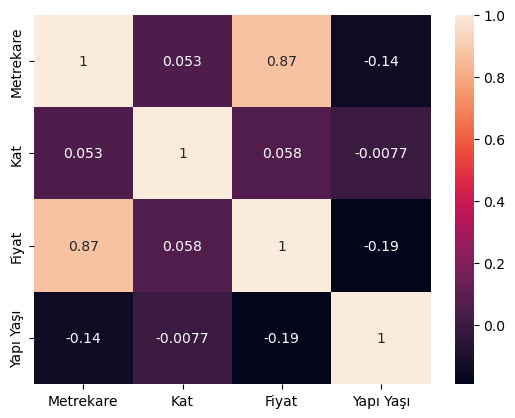

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [12]:
#Feature Engineering

In [13]:
df['Baslik'] = df['Başlık'].str.lower()                          # küçük harfe çevir
df['Baslik'] = df['Baslik'].str.replace('\d+', '', regex=True)   # rakamları kaldır
df['Baslik'] = df['Baslik'].str.replace('\n|\r', ' ', regex=True) # satır sonlarını boşluğa çevir
df['Baslik'] = df['Baslik'].str.replace(r'[^\w\s]', '', regex=True) # noktalama kaldır
df['Baslik'] = df['Baslik'].str.strip()                    # baş/son boşlukları temizle

In [14]:
df[df['Baslik'].str.contains('satılık')]

,Başlık,Konum,Oda Sayısı,Metrekare,Kat,Fiyat,Yapı Yaşı,Eşya,Isıtma,URL,Baslik
86,Ayışığından Yeni Binada 1+0 50 M2 Satılık Daire,İstanbul / Bahçelievler / Bahçelievler Mah.,1+0,50,1,20000,0,Eşyasız,Klima (Split),https://www.hepsiemlak.com/istanbul-bahcelievl...,ayışığından yeni binada m satılık daire
92,Ev-Ser’den 5.Levent Korupark Acil Büyük Tip 4+...,İstanbul / Eyüpsultan / 5. Levent Mah.,4+1,187,10,117000,4,Eşyasız,Yerden Isıtma,https://www.hepsiemlak.com/istanbul-eyupsultan...,evserden levent korupark acil büyük tip satılık
2476,Çekmeköy Sosyal Donatılı Site İçi 3+1 Boş Satı...,İstanbul / Çekmeköy / Cumhuriyet Mah.,3+1,152,4,96500,5,Eşyasız,Klima (Split),https://www.hepsiemlak.com/istanbul-cekmekoy-c...,çekmeköy sosyal donatılı site içi boş satılık...
4876,Başakkent Gölet 4+1 Geniş Ferah Temiz Satılık ...,İstanbul / Başakşehir / Bahçeşehir 2. Kısım Mah.,4+1,190,10,96500,6,Eşyalı,Merkezi,https://www.hepsiemlak.com/istanbul-basaksehir...,başakkent gölet geniş ferah temiz satılık daire
5676,Bahçeşehir Konakları Muhteşem Manzara 6+2 Satı...,İstanbul / Başakşehir / Bahçeşehir 1. Kısım Mah.,6+2,412,13,245000,5,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-basaksehir...,bahçeşehir konakları muhteşem manzara satılık...
7420,Satılık Bağlar Çeşme Kiralık Daire 100 Metre,İstanbul / Esenyurt / Çınar Mah.,2+1,94,8,20000,19,Eşyalı,Kombi,https://www.hepsiemlak.com/istanbul-esenyurt-c...,satılık bağlar çeşme kiralık daire metre
8089,Ispartakule Ebruli Sitesi 3+1 Satılık Daire,İstanbul / Avcılar / Tahtakale Mah.,3+1,139,3,47000,7,Eşyasız,Soba/Doğalgaz,https://www.hepsiemlak.com/istanbul-avcilar-ta...,ispartakule ebruli sitesi satılık daire
9212,Eyüpsultan Esentepe'de Merkezı Konumda 2+1 Sat...,İstanbul / Eyüpsultan / Esentepe Mah.,2+1,99,5,53000,6,Eşyalı,Kombi,https://www.hepsiemlak.com/istanbul-eyupsultan...,eyüpsultan esentepede merkezı konumda satılık...
9349,Skyland 1+1 Satılık Boş Daire Vt Uygun,İstanbul / Sarıyer / Huzur Mah.,1+1,59,12,35500,6,Eşyasız,Merkezi,https://www.hepsiemlak.com/istanbul-sariyer-hu...,skyland satılık boş daire vt uygun
9449,Kordon İstanbul 1+1 Eşyalı Satılık Daire,İstanbul / Kağıthane / Hamidiye Mah.,1+1,55,11,20000,5,Eşyalı,Merkezi,https://www.hepsiemlak.com/istanbul-kagithane-...,kordon istanbul eşyalı satılık daire


In [15]:
df = df[~df['Baslik'].str.contains('satılık', case=False)]

In [16]:
df.shape

(9584, 11)

In [17]:
# İlçe kolonunu oluşturma 
df['Ilce'] = df['Konum'].str.split('/').str[1].str.strip()

# Mahalle kolonunu oluşturma
df['Mahalle'] = df['Konum'].str.split('/').str[2].str.strip().str.replace('Mah.', '', regex=False).str.strip()

In [18]:
#İlçe Bazında Ortalama Kira Fiyatı
import plotly.express as px

ilce_fiyat = df.groupby('Ilce')['Fiyat'].median().reset_index()
ilce_fiyat = ilce_fiyat.sort_values('Fiyat', ascending=False).head(20)

fig = px.bar(ilce_fiyat, 
             x='Ilce', y='Fiyat',
             color='Fiyat',
             color_continuous_scale='Blues',
             title='İlçe Bazında Ortalama Kira Fiyatı (Top 20)',
             labels={'Fiyat': 'Ort Fiyat (TL)', 'Ilce': 'İlçe'})
fig.show()

In [19]:
# İlçe Bazında Ortalama Metrekare
ilce_m2 = df.groupby('Ilce')['Metrekare'].median().reset_index()
ilce_m2 = ilce_m2.sort_values('Metrekare', ascending=False).head(20)

fig = px.bar(ilce_m2,
             x='Ilce', y='Metrekare',
             color='Metrekare',
             color_continuous_scale='RdPu',
             title='İlçe Bazında Ort Metrekare (Top 20)',
             labels={'Metrekare': 'Ort m²', 'Ilce': 'İlçe'})
fig.show()

In [20]:
# İlçe Bazında Ortalama Yapı Yaşı
ilce_yas = df.groupby('Ilce')['Yapı Yaşı'].median().reset_index()
ilce_yas = ilce_yas.sort_values('Yapı Yaşı', ascending=False).head(20)

fig = px.bar(ilce_yas,
             x='Ilce', y='Yapı Yaşı',
             color='Yapı Yaşı',
             color_continuous_scale='YlGnBu',
             title='İlçe Bazında Ort Yapı Yaşı (Top 20)',
             labels={'Yapı Yaşı': 'Ort Yapı Yaşı', 'Ilce': 'İlçe'})
fig.show()

In [21]:
# İlçe Bazında Fiyat + Metrekare + Yapı Yaşı
ilce_ozet = df.groupby('Ilce').agg(
    Fiyat      = ('Fiyat', 'median'),
    Metrekare  = ('Metrekare', 'median'),
    YapiYasi   = ('Yapı Yaşı', 'median'),
    Adet       = ('Fiyat', 'count')
).reset_index()

fig = px.scatter(ilce_ozet,
                 x='Metrekare', y='Fiyat',
                 size='Adet',
                 color='YapiYasi',
                 color_continuous_scale='turbo',
                 hover_name='Ilce',
                 title='İlçe Bazında Fiyat - Metrekare - Yapı Yaşı',
                 labels={
                     'Fiyat'     : 'Ortalama Fiyat (TL)',
                     'Metrekare' : 'Ortalama m²',
                     'YapiYasi'  : 'Yapı Yaşı',
                     'Adet'      : 'İlan Sayısı'
                 })
fig.show()

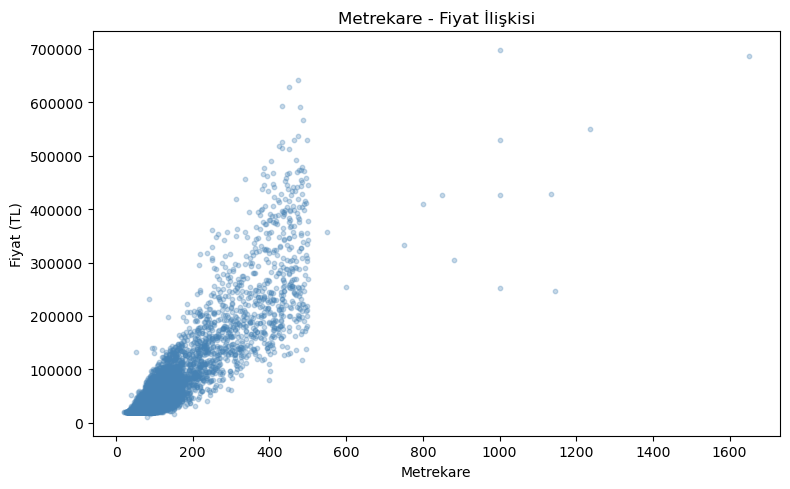

In [22]:
# Metrekare - Fiyat İlişkisi
plt.figure(figsize=(8, 5))
plt.scatter(df['Metrekare'], df['Fiyat'], alpha=0.3, color='steelblue', s=10)
plt.title('Metrekare - Fiyat İlişkisi')
plt.xlabel('Metrekare')
plt.ylabel('Fiyat (TL)')
plt.tight_layout()
plt.show()

In [23]:
df['KatKategori'] = pd.cut(df['Kat'], 
    bins=[-np.inf, -1, 0, 2, 7, 10, np.inf],
    labels=['Bodrum', 'Zemin Kat', 'Düşük Kat', 'Orta Kat', 'Yüksek Kat', 'Çok Yüksek Kat'])

In [24]:
df['BinaKategori'] = pd.cut(df['Yapı Yaşı'],
                             bins=[-1, 0, 5, 10, 20, 100],
                             labels=['Sıfır', 'YeniYapı', 'OrtaYaş', 'Eski', 'ÇokEski'])

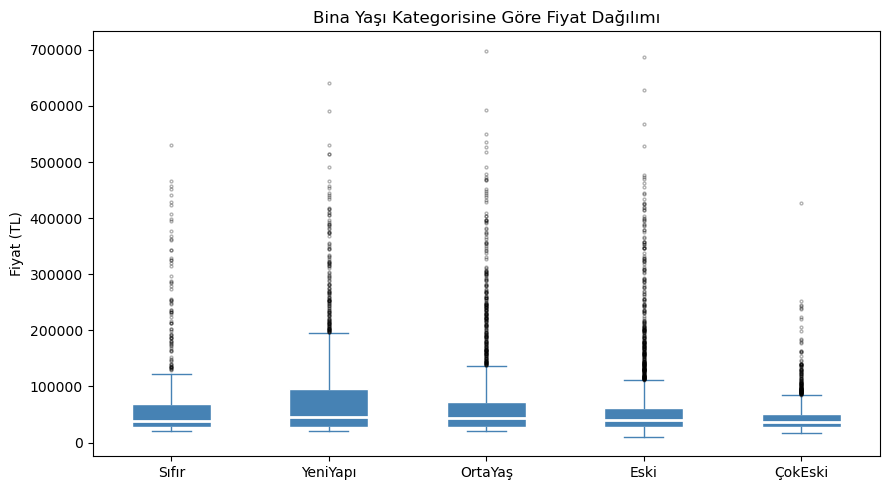

In [25]:
# Bina Yaşı - Fiyat
bina_order = ['Sıfır', 'YeniYapı', 'OrtaYaş', 'Eski', 'ÇokEski']
bina_data  = [df[df['BinaKategori'] == k]['Fiyat'].values for k in bina_order]

plt.figure(figsize=(9, 5))
plt.boxplot(bina_data, labels=bina_order, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='white'),
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(color='steelblue'),
            capprops=dict(color='steelblue'),
            flierprops=dict(marker='o', markersize=2, alpha=0.3, color='steelblue'))
plt.title('Bina Yaşı Kategorisine Göre Fiyat Dağılımı')
plt.ylabel('Fiyat (TL)')
plt.tight_layout()
plt.show()

In [26]:
#Boğaz Manzaralı
df['BogazManzarali'] = df['Baslik'].apply(lambda x: 'boğaz' in x and 'manzara' in x)

In [27]:
#Manzara
df['Manzarali'] = df['Baslik'].apply(lambda x: 'manzara' in x)

In [28]:
# Dubleks, Triplex veya teraslı geçenler
df['Dubleks'] = df['Baslik'].str.contains('dubleks|teraslı', case=False, na=False)
df['Tripleks'] = df['Baslik'].str.contains('tripleks|triplex', case=False, na=False)

In [29]:
# Metro veya metrobüs veya marmaray 
df['TopluTasima'] = df['Baslik'].str.contains('metro|metrobüs|marmaray', case=False, na=False)

# Hem metro hem metrobüs
df['TopluTasima2x'] = df['Baslik'].apply(lambda x: 'metro' in str(x).lower() and 'metrobüs' in str(x).lower())

In [30]:
# Üni veya ünv veya üniversite
df['Universite'] = df['Baslik'].str.contains('üni|ünv|üniversite', case=False, na=False)

In [31]:
# Hastane
df['Hastane'] = df['Baslik'].str.contains('hastane', case=False, na=False)

In [32]:
# Havuz
df['Havuz'] = df['Baslik'].str.contains('havuz', case=False, na=False)

In [33]:
# Balkon
df['Balkon'] = df['Baslik'].str.contains('balkon', case=False, na=False)

In [34]:
# Lüks ya da lüx ya da lux 
df['Luks'] = df['Baslik'].str.contains('lüks|lüx|lux', case=False, na=False)

In [35]:
# Cadde geçenler
df['Cadde'] = df['Baslik'].str.contains('cadde', case=False, na=False)

In [36]:
# Residence ya da rezidans
df['Rezidans'] = df['Baslik'].str.contains('residence|rezidans', case=False, na=False)

In [37]:
# AVM
df['AvmyeYakinlik'] = df['Baslik'].str.contains('avm', case=False, na=False)

In [38]:
# Asansör 
df['Asansor'] = df['Baslik'].str.contains('asansör', case=False, na=False)

In [39]:
# Site ya da konak
df['Site'] = df['Baslik'].str.contains('site|konak', case=False, na=False)

In [40]:
# Villa 
df['Villa'] = df['Baslik'].str.contains('villa', case=False, na=False)

# Yalı
df['Yali'] = df['Baslik'].str.contains('yalı', case=False, na=False)

In [41]:
# Güvenlik
df['Guvenlik'] = df['Baslik'].str.contains('güvenlik', case=False, na=False)

In [42]:
# Otopark
df['Otopark'] = df['Baslik'].str.contains('otopark', case=False, na=False)

In [43]:
# Orman ya da doğaya yakınlık
df['DogayaYakinlik'] = df['Baslik'].str.contains('orman|doğa|doga', case=False, na=False)

In [44]:
# Peyzaj ya da peysaj 
df['Peyzaj'] = df['Baslik'].str.contains('peyzaj|peysaj', case=False, na=False)

# Bahçe
df['Bahce'] = df['Baslik'].str.contains('bahçe', case=False, na=False)

In [45]:
# Sahil ya da iskele ya da deniz
df['SahileYakinlik'] = df['Baslik'].str.contains('sahil|iskele|deniz', case=False, na=False)

In [46]:
# Tadilat ya da yenilenmiş
df['Restorasyon'] = df['Baslik'].str.contains('tadilat|yenilenmiş', case=False, na=False)

In [47]:
# Merkez ya da meydan
df['MerkezeYakinlik'] = df['Baslik'].str.contains('merkez|meydan', case=False, na=False)

In [48]:
# Okul ya da kolej 
df['OkulaYakinlik'] = df['Baslik'].str.contains('okul|kolej|lise', case=False, na=False)

In [49]:
# Havaalanı
df['HavaalanınaYakinlik'] = df['Baslik'].str.contains('havaalanı', case=False, na=False)

In [50]:
# Bodrum
df['Bodrum'] = df['Baslik'].str.contains('bodrum', case=False, na=False)

In [51]:
# Sıfır Yapı
df['Sıfır'] = df['Baslik'].str.contains('sıfır', case=False, na=False)

In [52]:
df.head()

,Başlık,Konum,Oda Sayısı,Metrekare,Kat,Fiyat,Yapı Yaşı,Eşya,Isıtma,URL,...,DogayaYakinlik,Peyzaj,Bahce,SahileYakinlik,Restorasyon,MerkezeYakinlik,OkulaYakinlik,HavaalanınaYakinlik,Bodrum,Sıfır
0,Sarıyer Tarabya Boğaz Manzaralı Tripleks Bahçe...,İstanbul / Sarıyer / Tarabya Mah.,4+1,397,9,433000,7,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-sariyer-ta...,...,False,False,True,False,False,False,False,False,False,False
1,Esenyurt Royal Garden 1+1 Kiralık Eşyalı Şehir...,İstanbul / Esenyurt / Barbaros Hayrettin Paşa ...,1+1,53,2,20000,7,Eşyalı,Soba/Doğalgaz,https://www.hepsiemlak.com/istanbul-esenyurt-b...,...,False,False,False,False,False,False,False,False,False,False
2,Sultanbeyli'de Saklı Bahçe Evleri Sitesinde Ki...,İstanbul / Sultanbeyli / Akşemsettin Mah.,3+1,167,1,47500,8,Eşyasız,Merkezi,https://www.hepsiemlak.com/istanbul-sultanbeyl...,...,False,False,True,False,False,False,False,False,False,False
3,Havaalanına Komşu Havuzlu Site İçinde Kiralık ...,İstanbul / Pendik / Çamlık Mah.,3+1,126,9,46000,18,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-pendik-cam...,...,False,False,False,False,False,False,False,True,False,False
4,Çok Merkezi Konumda 2. Kat Aydınlık Boş Kiral...,İstanbul / Beyoğlu / Firuzağa Mah.,2+1,86,2,56000,7,Eşyalı,Merkezi,https://www.hepsiemlak.com/istanbul-beyoglu-fi...,...,False,False,False,False,False,True,False,False,False,False


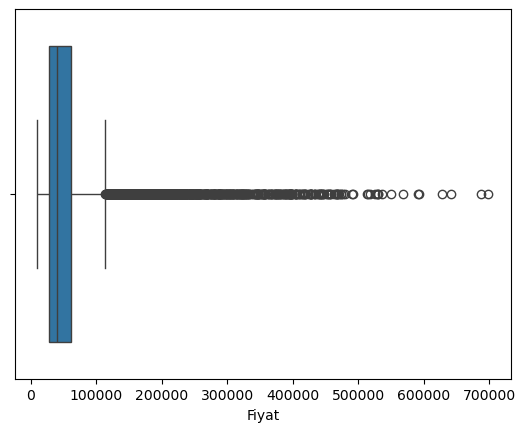

In [53]:
sns.boxplot(x=df['Fiyat']);  

In [54]:
df['Fiyat'].mean()+3*df['Fiyat'].std()

np.float64(260392.7236647159)

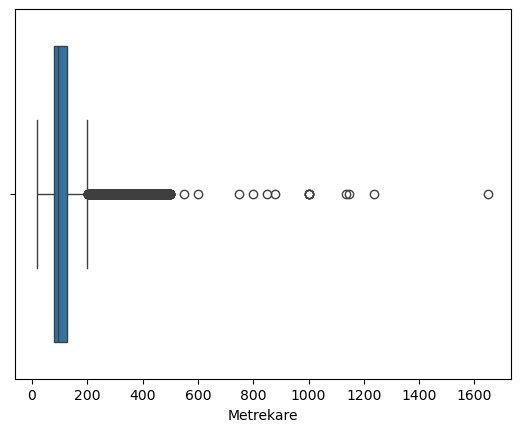

In [55]:
sns.boxplot(x=df['Metrekare']);  

In [56]:
df['Metrekare'].mean()+3*df['Metrekare'].std()

np.float64(392.47343111241634)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9584 entries, 0 to 9595
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Başlık               9584 non-null   object  
 1   Konum                9584 non-null   object  
 2   Oda Sayısı           9584 non-null   object  
 3   Metrekare            9584 non-null   int64   
 4   Kat                  9584 non-null   int64   
 5   Fiyat                9584 non-null   int64   
 6   Yapı Yaşı            9584 non-null   int64   
 7   Eşya                 9584 non-null   object  
 8   Isıtma               9584 non-null   object  
 9   URL                  9584 non-null   object  
 10  Baslik               9584 non-null   object  
 11  Ilce                 9584 non-null   object  
 12  Mahalle              9584 non-null   object  
 13  KatKategori          9584 non-null   category
 14  BinaKategori         9584 non-null   category
 15  BogazManzarali       9584 

In [58]:
# Oda ve Salon sayısını ayrı ayrı alalım
df['OdaSayisi'] = df['Oda Sayısı'].str.split('+').str[0].astype(int)
df['SalonSayisi'] = df['Oda Sayısı'].str.split('+').str[1].astype(int)

In [59]:
premium_kolonlar = ['BogazManzarali', 'Manzarali', 'Havuz', 'Guvenlik', 
                    'Otopark', 'Asansor', 'Balkon', 'Bahce', 'Luks', 
                    'Rezidans', 'Yali', 'Villa', 'Peyzaj']

df['PremiumSkor'] = df[premium_kolonlar].sum(axis=1)

In [60]:
ulasim_kolonlar = ['TopluTasima', 'TopluTasima2x', 'AvmyeYakinlik', 
                   'HavaalanınaYakinlik', 'MerkezeYakinlik']

df['UlasimSkor'] = df[ulasim_kolonlar].sum(axis=1)

In [61]:
# Eşya
df['Esya'] = df['Eşya'].map({'Eşyalı': 1, 'Eşyasız': 0})

In [62]:
df.isnull().sum()

Başlık                 0
Konum                  0
Oda Sayısı             0
Metrekare              0
Kat                    0
Fiyat                  0
Yapı Yaşı              0
Eşya                   0
Isıtma                 0
URL                    0
Baslik                 0
Ilce                   0
Mahalle                0
KatKategori            0
BinaKategori           0
BogazManzarali         0
Manzarali              0
Dubleks                0
Tripleks               0
TopluTasima            0
TopluTasima2x          0
Universite             0
Hastane                0
Havuz                  0
Balkon                 0
Luks                   0
Cadde                  0
Rezidans               0
AvmyeYakinlik          0
Asansor                0
Site                   0
Villa                  0
Yali                   0
Guvenlik               0
Otopark                0
DogayaYakinlik         0
Peyzaj                 0
Bahce                  0
SahileYakinlik         0
Restorasyon            0


In [63]:
# Nulları medyanla dolduralım ya da silsek de olur
#df['Isıtma'].fillna(df['Isıtma'].median(), inplace=True)

In [64]:
df.head()

,Başlık,Konum,Oda Sayısı,Metrekare,Kat,Fiyat,Yapı Yaşı,Eşya,Isıtma,URL,...,MerkezeYakinlik,OkulaYakinlik,HavaalanınaYakinlik,Bodrum,Sıfır,OdaSayisi,SalonSayisi,PremiumSkor,UlasimSkor,Esya
0,Sarıyer Tarabya Boğaz Manzaralı Tripleks Bahçe...,İstanbul / Sarıyer / Tarabya Mah.,4+1,397,9,433000,7,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-sariyer-ta...,...,False,False,False,False,False,4,1,3,0,0
1,Esenyurt Royal Garden 1+1 Kiralık Eşyalı Şehir...,İstanbul / Esenyurt / Barbaros Hayrettin Paşa ...,1+1,53,2,20000,7,Eşyalı,Soba/Doğalgaz,https://www.hepsiemlak.com/istanbul-esenyurt-b...,...,False,False,False,False,False,1,1,1,0,1
2,Sultanbeyli'de Saklı Bahçe Evleri Sitesinde Ki...,İstanbul / Sultanbeyli / Akşemsettin Mah.,3+1,167,1,47500,8,Eşyasız,Merkezi,https://www.hepsiemlak.com/istanbul-sultanbeyl...,...,False,False,False,False,False,3,1,1,0,0
3,Havaalanına Komşu Havuzlu Site İçinde Kiralık ...,İstanbul / Pendik / Çamlık Mah.,3+1,126,9,46000,18,Eşyasız,Kombi,https://www.hepsiemlak.com/istanbul-pendik-cam...,...,False,False,True,False,False,3,1,1,1,0
4,Çok Merkezi Konumda 2. Kat Aydınlık Boş Kiral...,İstanbul / Beyoğlu / Firuzağa Mah.,2+1,86,2,56000,7,Eşyalı,Merkezi,https://www.hepsiemlak.com/istanbul-beyoglu-fi...,...,True,False,False,False,False,2,1,0,1,1


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9584 entries, 0 to 9595
Data columns (total 50 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Başlık               9584 non-null   object  
 1   Konum                9584 non-null   object  
 2   Oda Sayısı           9584 non-null   object  
 3   Metrekare            9584 non-null   int64   
 4   Kat                  9584 non-null   int64   
 5   Fiyat                9584 non-null   int64   
 6   Yapı Yaşı            9584 non-null   int64   
 7   Eşya                 9584 non-null   object  
 8   Isıtma               9584 non-null   object  
 9   URL                  9584 non-null   object  
 10  Baslik               9584 non-null   object  
 11  Ilce                 9584 non-null   object  
 12  Mahalle              9584 non-null   object  
 13  KatKategori          9584 non-null   category
 14  BinaKategori         9584 non-null   category
 15  BogazManzarali       9584 

In [66]:
#Correlation by Fiyat
abs(df.corr(numeric_only=True))['Fiyat'].sort_values(ascending=False)

Fiyat                  1.000000
Metrekare              0.870893
OdaSayisi              0.410882
Dubleks                0.405896
Villa                  0.398777
SalonSayisi            0.219479
Yapı Yaşı              0.192509
PremiumSkor            0.125196
Manzarali              0.121355
Tripleks               0.119261
SahileYakinlik         0.110296
BogazManzarali         0.104717
Bahce                  0.098941
Yali                   0.096494
Havuz                  0.096173
UlasimSkor             0.078786
TopluTasima            0.061175
Kat                    0.057397
TopluTasima2x          0.057023
Balkon                 0.051701
DogayaYakinlik         0.046455
Site                   0.046425
Esya                   0.045764
Rezidans               0.036065
MerkezeYakinlik        0.030875
Restorasyon            0.028726
Peyzaj                 0.027964
AvmyeYakinlik          0.027559
Luks                   0.025157
Universite             0.018466
Bodrum                 0.015090
Hastane 

In [67]:
features = [
    'Metrekare',
    'OdaSayisi',
    'SalonSayisi',
    'Kat',  
    'Yapı Yaşı',
    'Villa', 
    'Dubleks', 
    'Tripleks', 
    'Yali',
    'BogazManzarali', 
    'Manzarali', 
    'SahileYakinlik',
    'Bahce', 
    'Havuz',
    'Ilce', 
    'Mahalle',
    'UlasimSkor'
    
]

x = df[features]

In [68]:
x.head()

,Metrekare,OdaSayisi,SalonSayisi,Kat,Yapı Yaşı,Villa,Dubleks,Tripleks,Yali,BogazManzarali,Manzarali,SahileYakinlik,Bahce,Havuz,Ilce,Mahalle,UlasimSkor
0,397,4,1,9,7,False,False,True,False,True,True,False,True,False,Sarıyer,Tarabya,0
1,53,1,1,2,7,False,False,False,True,False,False,False,False,False,Esenyurt,Barbaros Hayrettin Paşa,0
2,167,3,1,1,8,False,False,False,False,False,False,False,True,False,Sultanbeyli,Akşemsettin,0
3,126,3,1,9,18,False,False,False,False,False,False,False,False,True,Pendik,Çamlık,1
4,86,2,1,2,7,False,False,False,False,False,False,False,False,False,Beyoğlu,Firuzağa,1


In [69]:
x=pd.get_dummies(x, drop_first=True)

In [70]:
x.shape

(9584, 649)

In [71]:
y=df['Fiyat']

In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
lr=LinearRegression()

In [75]:
model=lr.fit(x_train, y_train)

In [76]:
tahmin=lr.predict(x_test)

In [77]:
r2_score(y_test,tahmin)

0.8687906290901313

In [78]:
mean_squared_error(y_test,tahmin)**0.5

24482.398971253104

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [80]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.938914,16704.897485,7638.396484
Gradient Boosting,0.903730,20970.868544,11267.581269
Ridge,0.871649,24214.221811,12139.887225
Lasso,0.869528,24413.471018,12215.373757
Linear,0.868791,24482.398971,12378.317535
Decision Tree,0.842730,26803.709384,11369.066249
Extra Tree,0.826208,28176.441248,11180.490350
ElasticNet,0.775683,32011.244825,17876.505250
KNeighborsRegressor,0.748999,33861.764383,19145.800730


In [81]:
#pip uninstall yellowbrick scikit-learn -y

In [82]:
#pip install scikit-learn yellowbrick

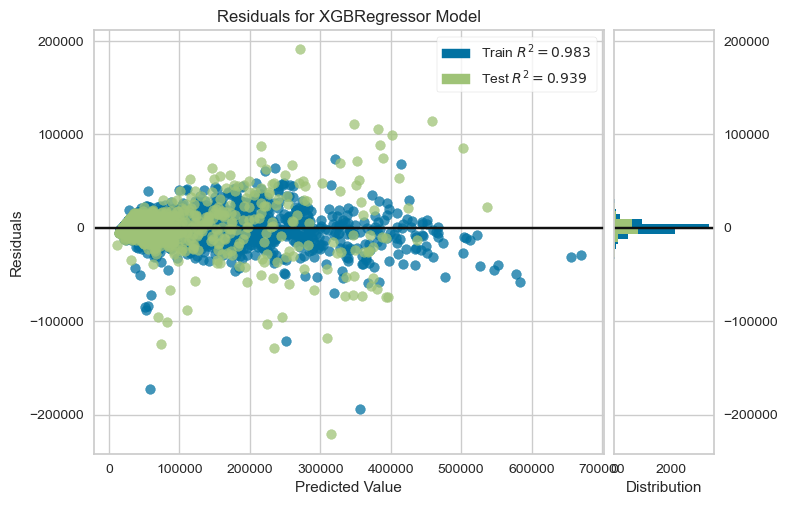

<Axes: title={'center': 'Residuals for XGBRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [83]:
from yellowbrick.regressor import ResidualsPlot


model = XGBRegressor()
model.fit(x_train, y_train)
tahmin = model.predict(x_test)


vis = ResidualsPlot(model, force_model=True)
vis.fit(x_train, y_train)
vis.score(x_test, y_test)
vis.show()

In [84]:
residuals=y_test-tahmin

<Axes: xlabel='Fiyat', ylabel='Density'>

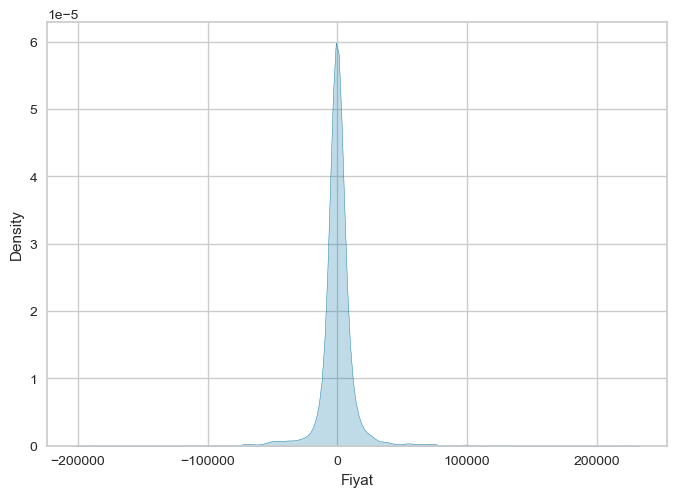

In [85]:
sns.kdeplot(x=residuals, fill=True)

In [86]:
karsilastirma=pd.DataFrame()
karsilastirma['GercekFiyat']=y_test
karsilastirma['Tahmin']=tahmin
karsilastirma.head()

,GercekFiyat,Tahmin
3671,43000,39989.324219
7053,48500,61381.597656
2438,33000,32641.183594
4613,21500,19834.154297
5944,31000,32425.515625


In [87]:
# Regression with Deep Learning

In [88]:
x = df[[                    
    'Metrekare',
    'OdaSayisi',
    'SalonSayisi',
    'Kat',
    'Yapı Yaşı',
    'Villa',
    'Dubleks',
    'Tripleks',
    'Yali',
    'BogazManzarali',
    'Manzarali',
    'SahileYakinlik',
    'Bahce',
    'Havuz',
    'Ilce',
    'Mahalle',
    'UlasimSkor'
]]

y = df['Fiyat']

In [89]:
x=pd.get_dummies(x, drop_first=True)

In [90]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) 
x_test  = scaler.transform(x_test)

In [92]:
model = Sequential([
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)                               
])

model.compile(loss='mean_squared_error', optimizer='adam')

In [93]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=64, callbacks=[early_stop], verbose=1)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 8050112512.0000 - val_loss: 8173061120.0000
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6981627904.0000 - val_loss: 5439481856.0000
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3259460608.0000 - val_loss: 1285641600.0000
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1135342848.0000 - val_loss: 758207040.0000
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 827311744.0000 - val_loss: 620056960.0000
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 691151744.0000 - val_loss: 489145632.0000
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 570661632.0000 - val_loss: 487669760.0000
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 517150016.0000 - val_loss: 449383552.0000
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 515479328.0000 - val_loss: 471243232.0000
Epoch 10/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - 

In [94]:
tahmin = model.predict(x_test).flatten()

print(f"R²  : {r2_score(y_test, tahmin):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, tahmin)):,.0f}")
print(f"MAE : {mean_absolute_error(y_test, tahmin):,.0f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
R²  : 0.9266
RMSE: 18,316
MAE : 9,405


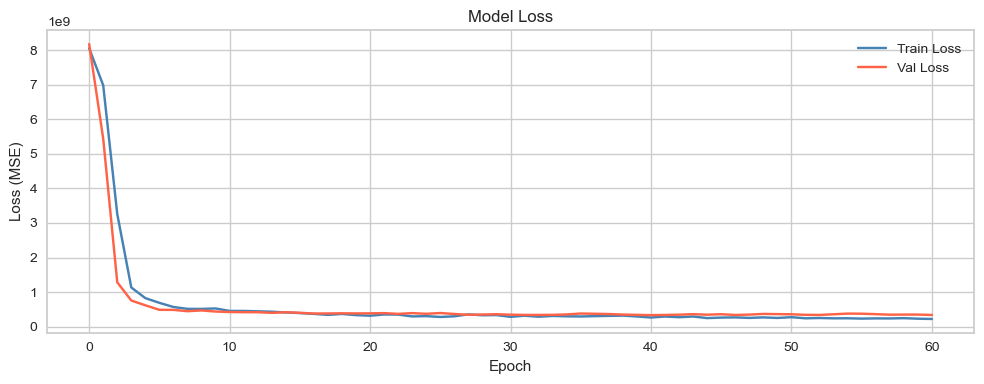

In [95]:
#Loss Grafiği
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
import pickle
import json
from tensorflow.keras.models import save_model

# Scaler'ı kaydet
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Kolon sırasını kaydet
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(x.columns), f)

# Modeli kaydet
model.save('istanbul_rent_model.h5')

print("Model, scaler ve kolonlar kaydedildi!")
print(f"Kolon sayısı: {len(x.columns)}")

Model, scaler ve kolonlar kaydedildi!
Kolon sayısı: 649


Bu çalışma kapsamında oluşturulan veri seti üzerinde farklı makine öğrenmesi ve derin öğrenme modelleri uygulanarak kira fiyatı tahmin performansları karşılaştırılmıştır. Elde edilen sonuçlara göre, en yüksek performans XGBRegressor modeli tarafından elde edilmiştir (R²: 0.937, RMSE: 16,984, MAE: 7,648). Gradient Boosting, Ridge, Linear Regression ve Lasso gibi modeller de görece yüksek başarı sağlamış ancak hata oranları bakımından XGBoost’un gerisinde kalmıştır. Derin öğrenme modeli ise R²: 0.9296, RMSE: 17,958 ve MAE: 8,181 değerleri ile güçlü bir performans sergilemiş, ancak en iyi sonucu veren modelin biraz altında kalmıştır.